
# This program is used to simulate a state which have 9000 precincts

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import jensenshannon
from scipy.optimize import minimize
from sklearn.metrics import r2_score


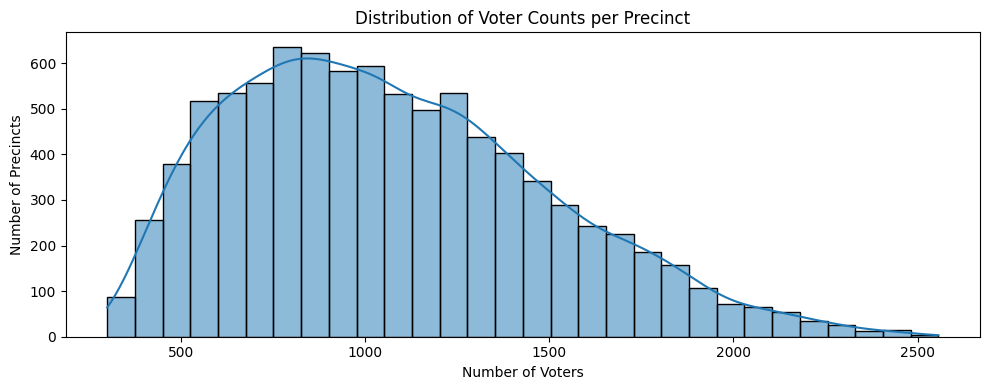

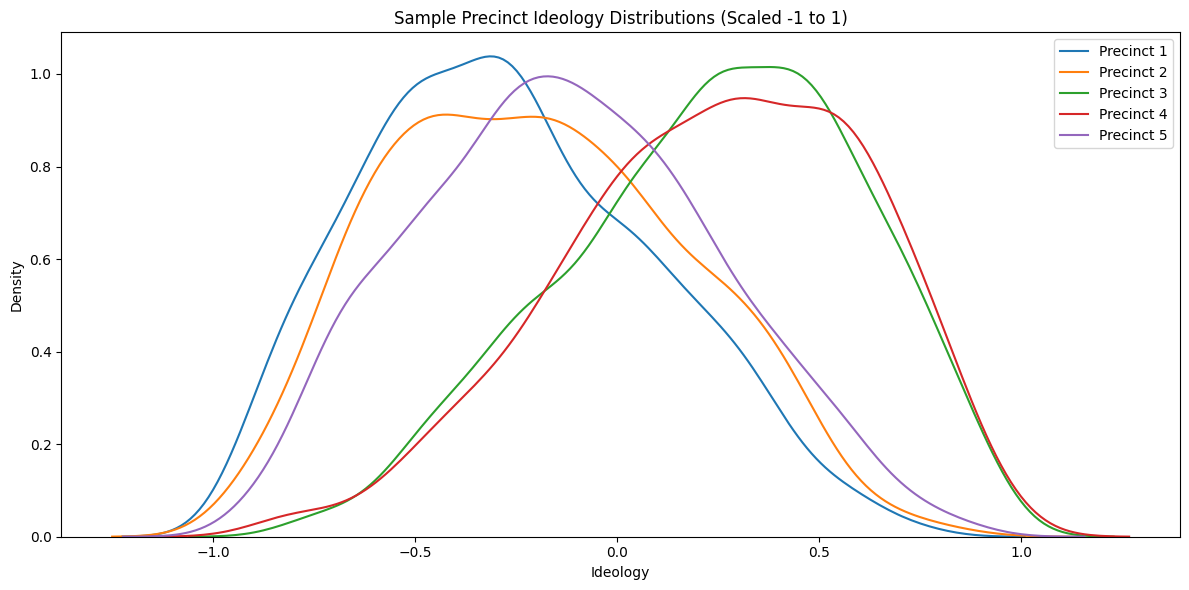

In [42]:
# Parameters
set_random_seed = 42
np.random.seed(set_random_seed)
num_precincts = 9000
min_voters = 300
max_voters = 3000

# Generate right-skewed number of voters per precinct using Beta(2, 5)
voter_counts = (np.random.beta(a=2, b=5, size=num_precincts) * (max_voters - min_voters) + min_voters).astype(int)

# Store ideology distributions for all precincts
all_precinct_ideologies = []

# Randomly generate (a, b) parameters for beta distribution for ideology
a_values = np.random.uniform(2, 4, num_precincts)
b_values = 6 - a_values

# Generate population ideologies for each precinct based on their voter count
for a, b, n in zip(a_values, b_values, voter_counts):
    population_ideologies = np.random.beta(a=a, b=b, size=n) * 2 - 1
    all_precinct_ideologies.append(population_ideologies)

# Optional: Plot distribution of precinct sizes
plt.figure(figsize=(10, 4))
sns.histplot(voter_counts, bins=30, kde=True)
plt.title("Distribution of Voter Counts per Precinct")
plt.xlabel("Number of Voters")
plt.ylabel("Number of Precincts")
plt.tight_layout()
plt.show()

# Plot a few example precinct distributions
plt.figure(figsize=(12, 6))
for i in range(5):
    sns.kdeplot(all_precinct_ideologies[i], label=f'Precinct {i+1}')
plt.title("Sample Precinct Ideology Distributions (Scaled -1 to 1)")
plt.xlabel("Ideology")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()



In [33]:
print(f"Min: {population_ideologies.min():.4f}, Max: {population_ideologies.max():.4f}")


Min: -0.9106, Max: 0.9854


In [ ]:
population_ideologies

array([ 0.37910808, -0.70074913, -0.19832519, ...,  0.05015087,
        0.46134556, -0.12771626])

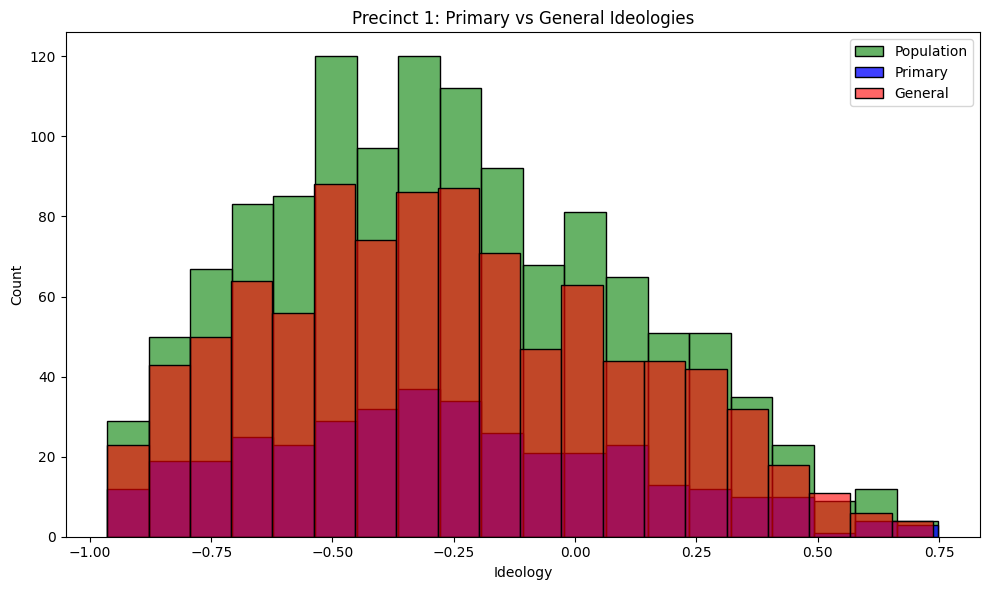

In [44]:
# Initialize new containers
primary_ideologies_allprecinct = []
general_ideologies_allprecinct = []
primary_vote_margins = []

# Updated simulation using all_precinct_ideologies
for population_ideologies in all_precinct_ideologies:
    # Sample turnout rates
    num_total_voters = len(population_ideologies)
    # Sample random turnout rates
    primary_turnout = np.random.uniform(0.20, 0.35)
    general_turnout = np.random.uniform(0.55, 0.80)

    # Sample primary and general voters
    num_primary = int(primary_turnout * num_total_voters)
    num_general = int(general_turnout * num_total_voters)

    primary_indices = np.random.choice(np.arange(num_total_voters), size=num_primary, replace=False)
    general_indices = np.random.choice(np.arange(num_total_voters), size=num_general, replace=False)

    primary_votes = population_ideologies[primary_indices]
    general_votes = population_ideologies[general_indices]

    # Store ideologies
    primary_ideologies_allprecinct.append(primary_votes)
    general_ideologies_allprecinct.append(general_votes)

    # Count Democrat (<= 0) vs Republican (> 0) votes
    dem_primary = np.sum(primary_votes <= 0)
    rep_primary = num_primary - dem_primary

    # Compute margin: |D - R| / (D + R)
    primary_margin = abs(dem_primary - rep_primary) / (dem_primary + rep_primary)
    primary_vote_margins.append(primary_margin)

# Show a sample of the collected ideology distributions
sample_index = 0
plt.figure(figsize=(10, 6))
sns.histplot(all_precinct_ideologies[sample_index], color='green', bins=20, label='Population', alpha=0.6)
sns.histplot(primary_ideologies_allprecinct[sample_index], color='blue', bins=20, label='Primary')
sns.histplot(general_ideologies_allprecinct[sample_index], color='red', bins=20, label='General', alpha=0.6)
plt.title(f"Precinct {sample_index + 1}: Primary vs General Ideologies")
plt.xlabel("Ideology")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


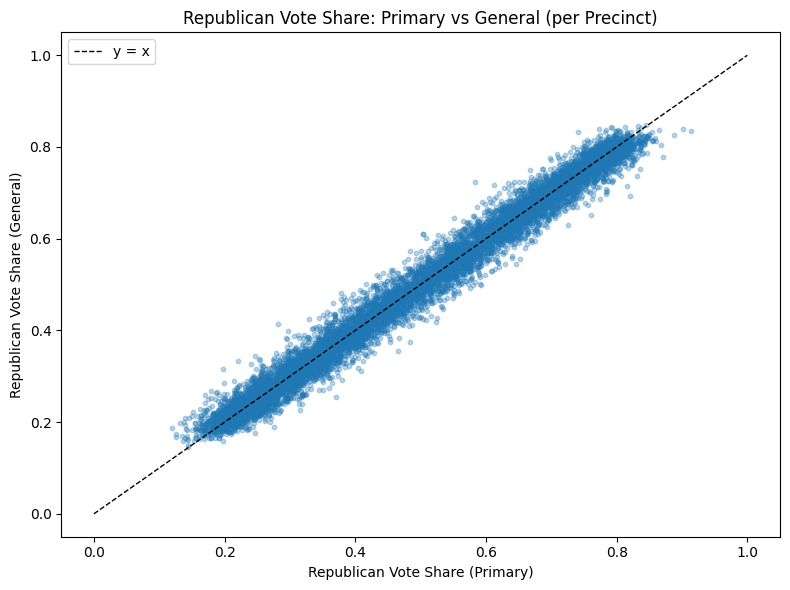

In [45]:

rep_share_primary = []
rep_share_general = []

for primary_votes, general_votes in zip(primary_ideologies_allprecinct, general_ideologies_allprecinct):
    rep_primary = np.sum(primary_votes > 0)
    rep_general = np.sum(general_votes > 0)
    rep_share_primary.append(rep_primary / len(primary_votes))
    rep_share_general.append(rep_general / len(general_votes))

# Scatter plot: Republican vote share in primary vs general
plt.figure(figsize=(8, 6))
plt.scatter(rep_share_primary, rep_share_general, alpha=0.3, s=10)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='y = x')
plt.xlabel("Republican Vote Share (Primary)")
plt.ylabel("Republican Vote Share (General)")
plt.title("Republican Vote Share: Primary vs General (per Precinct)")
plt.legend()
plt.tight_layout()
plt.show()
# ...existing code...

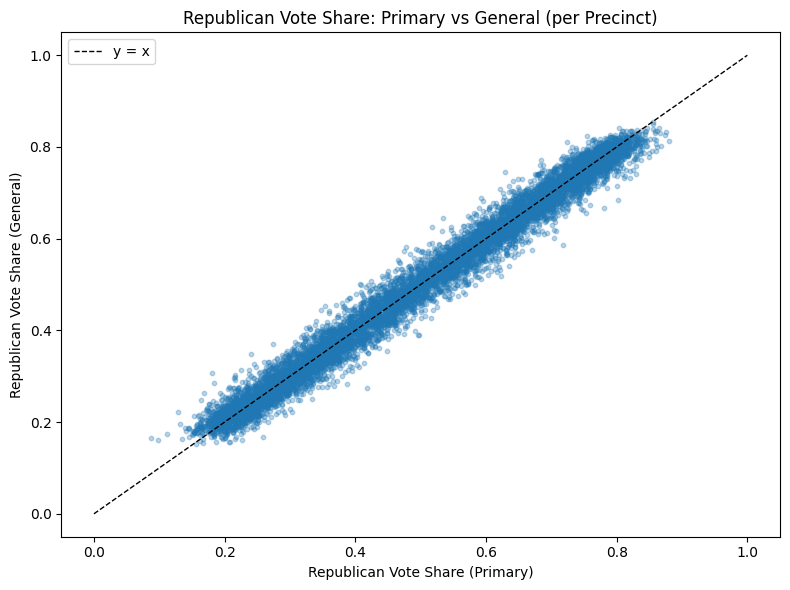

In [46]:

dem_share_primary = []
dem_share_general = []

for primary_votes, general_votes in zip(primary_ideologies_allprecinct, general_ideologies_allprecinct):
    dem_primary = np.sum(primary_votes <= 0)
    dem_general = np.sum(general_votes <= 0)
    dem_share_primary.append(dem_primary / len(primary_votes))
    dem_share_general.append(dem_general / len(general_votes))

# Scatter plot: Republican vote share in primary vs general
plt.figure(figsize=(8, 6))
plt.scatter(dem_share_primary, dem_share_general, alpha=0.3, s=10)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='y = x')
plt.xlabel("Republican Vote Share (Primary)")
plt.ylabel("Republican Vote Share (General)")
plt.title("Republican Vote Share: Primary vs General (per Precinct)")
plt.legend()
plt.tight_layout()
plt.show()
# ...existing code...

In [36]:
def turnout_model(margins, b, m1, m2):
    """
    Calculate turnout probabilities based on margins and model parameters.
    
    Args:
        margins (np.ndarray): Array of vote margins.
        b (float): Maximum vote probability at tie.
        m1 (float): Steeper slope for winner.
        m2 (float): Flatter slope for loser.
    
    Returns:
        np.ndarray: Turnout probabilities for the given margins.
    """
    prob_winner = b - m1 * margins
    prob_loser = b - m2 * margins
    return np.clip(prob_winner, 0, 1), np.clip(prob_loser, 0, 1)